In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from core import (
    list_files_oswalk,
    preprocess_audio_paths,
    preprocess_video_paths,
    get_video_embeddings_list,
    get_audio_embeddings_list,
)
from core import get_pseudo_highlight_scores
from core import SelfAttention, BimodalSelfAttention
from core import HighlightClassifier

from highlight_utils import (
    build_highlight_ranges_from_scores,
    time_ranges_to_segment_labels,
    split_scores_by_embeddings,
    to_padded_batch,
    render_global_highlights, 
    split_match_to_fixed_segments,
    RenderConfig
)

from scripts.generate_voiceover import create_voiceover_for_match

c:\D\UCU\AI\ai-highlight-pipeline\.venv-wind\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

match_video = "../data/matches/full_match_beic_barcelona.mp4"
out_root = "./output/match_processed"

d_self = 128
D_common = 256
d_bimodal = 128
hidden = 256
dropout = 0.5
lr = 1e-4
num_epochs = 100
batch_size = 8

alpha_logits = nn.Parameter(torch.zeros(4, device=device))

Using device: cuda


C:\Users\jenia\AppData\Local\Temp\ipykernel_7796\761280919.py:16: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  alpha_logits = nn.Parameter(torch.zeros(4, device=device))


### Prepare clips from match

In [4]:
video_root, audio_root = split_match_to_fixed_segments(
    match_video,
    out_root=out_root,
    seg_s=20
)
print("Video chunks in:", video_root)
print("Audio chunks in:", audio_root)

Video chunks in: output\match_processed\video_chunks
Audio chunks in: output\match_processed\audio_chunks


### Create voiceover

In [3]:
res = create_voiceover_for_match(
    video_path="./output/results/all_highlights_4min.mp4",
    home_team="Barcelona",
    away_team="BETIS",
    target_min=3.0,
    work_dir="output/voiceover",
)

[1/6] Extracting audio…
    Done in 0.31s
[2/6] Running Whisper STT…
    Segments: 92 | words: 748 | 206.49s
[3/6] Computing audio excitement…
    Excitement z-peak: 3.16 | 4.90s
[4/6] Fetching match/team analytics (API-Football)…
    Analytics keys: ['fixture', 'excitement_peak', 'home_form', 'away_form', 'home_key_players', 'away_key_players', 'h2h_count'] | 3.13s
[5/6] Generating script (English)…
[OpenAI] Fallback (reason: No module named 'openai' )
    Script saved -> output\voiceover\script.md | 0.00s
[6/6] Synthesizing voiceover (ElevenLabs, MP3)…
[TTS] Voice 'Bella' not found; using first available voice: Roger (CwhRBWXzGAHq8TQ4Fs17)
    Voiceover saved -> output\voiceover\voiceover.mp3 | 23.17s


### Loading paths and preprocessing into segments

In [ ]:
video_paths = list_files_oswalk(video_root, ext_filter={".mp4", ".avi", ".mov"})
audio_paths = list_files_oswalk(audio_root, ext_filter={".wav", ".mp3", ".flac"})
voiceover_audio_path = list_files_oswalk("output/voiceover", ext_filter={".wav", ".mp3", ".flac"})

video_paths.sort()
audio_paths.sort()
voiceover_audio_path.sort()

assert len(video_paths) == len(audio_paths), "Mismatch between # of videos and audios"
print(f"Found {len(video_paths)} video/audio pairs")

Found 330 video/audio pairs


In [4]:
video_segments_list, audios_duration, n_segments_list = preprocess_video_paths(video_paths)
audio_segments_list = preprocess_audio_paths(
    audio_paths,
    audios_duration,
    n_segments_list,
)

print("Segments per video:", n_segments_list)
print("Total segments (expected):", sum(n_segments_list))

Segments per video: [38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29, 29, 38, 29,

### Extracting embeddings

In [5]:
print("Extracting video embeddings...")
video_embeddings_list = get_video_embeddings_list(video_segments_list, device=device)

print("Extracting audio embeddings...")
audio_embeddings_list = get_audio_embeddings_list(audio_segments_list, device=device)

total_video_segs = sum(e.shape[0] for e in video_embeddings_list)
total_audio_segs = sum(e.shape[0] for e in audio_embeddings_list)

print("Total segments expected      :", sum(n_segments_list))
print("Video segments from embeddings:", total_video_segs)
print("Audio segments from embeddings:", total_audio_segs)

Extracting video embeddings...


NameError: name 'video_segments_list' is not defined

Saving embeddings:

In [6]:
import numpy as np

shapes_v = [np.asarray(x).shape for x in video_embeddings_list]
shapes_a = [np.asarray(x).shape for x in audio_embeddings_list]

print("video unique shapes:", sorted(set(shapes_v))[:10], "… total:", len(set(shapes_v)))
print("audio unique shapes:", sorted(set(shapes_a))[:10], "… total:", len(set(shapes_a)))


NameError: name 'video_embeddings_list' is not defined

In [8]:
np.savez(
    "cached_embeddings_full_match.npz",
    video=np.array(video_embeddings_list, dtype=object),
    audio=np.array(audio_embeddings_list, dtype=object),
    allow_pickle=True,
)

Reloading embeddings

In [6]:
loaded = np.load("./cached_embeddings_full_match.npz", allow_pickle=True)
video_embeddings_list = list(loaded["video"])
audio_embeddings_list = list(loaded["audio"])

print("Example embedding shape (first video):", video_embeddings_list[0].shape)

Example embedding shape (first video): torch.Size([38, 512])


### Pseudo-highlight scores (PHS)

c:\D\UCU\AI\ai-highlight-pipeline\.venv-wind\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[PHS] Searching optimal K in range [4, 15]...
[PHS] Selected optimal K=5
[Vis] Projecting features to 2D for visualization...


c:\D\UCU\AI\ai-highlight-pipeline\.venv-wind\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


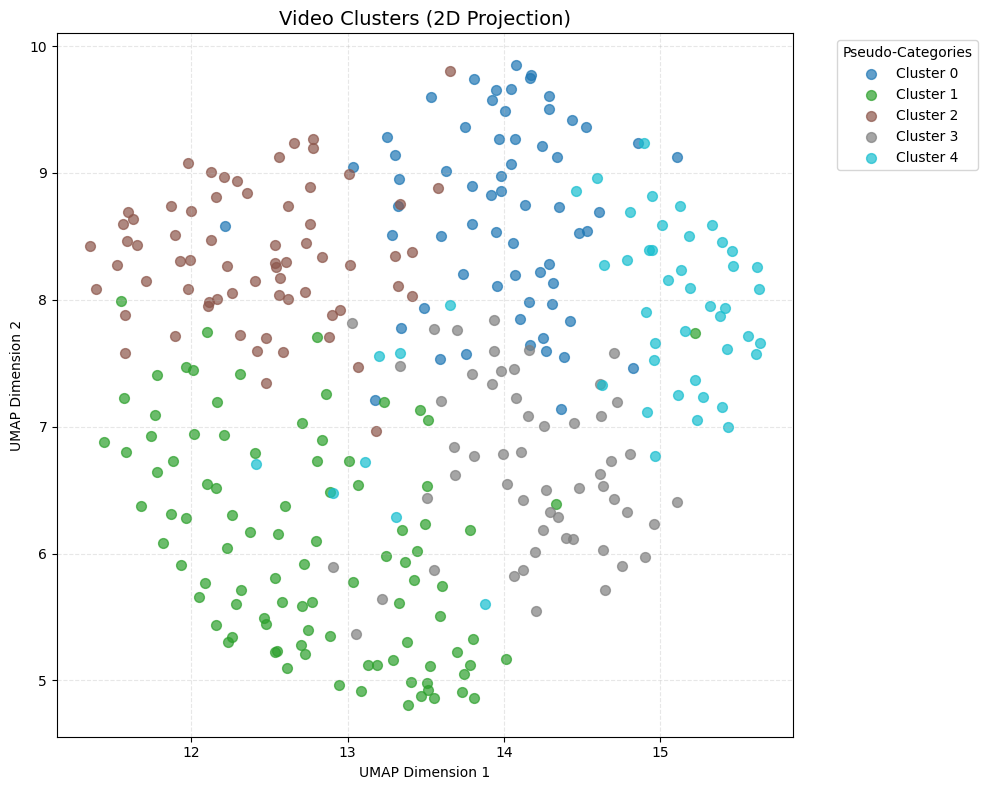

Pseudo scores length: 10545


In [7]:
pseudo_scores_flat = get_pseudo_highlight_scores(
    audio_embeddings_list=audio_embeddings_list,
    video_embeddings_list=video_embeddings_list,
)

print("Pseudo scores length:", len(pseudo_scores_flat))

In [ ]:
pseudo_scores_per_video = split_scores_by_embeddings(
    pseudo_scores_flat,
    video_embeddings_list,
)

for i, arr in enumerate(pseudo_scores_per_video):
    print(f"Video {i}: pseudo-score shape {arr.shape}")

Video 0: pseudo-score shape (38,)
Video 1: pseudo-score shape (29,)
Video 2: pseudo-score shape (29,)
Video 3: pseudo-score shape (38,)
Video 4: pseudo-score shape (29,)
Video 5: pseudo-score shape (29,)
Video 6: pseudo-score shape (38,)
Video 7: pseudo-score shape (29,)
Video 8: pseudo-score shape (29,)
Video 9: pseudo-score shape (38,)
Video 10: pseudo-score shape (29,)
Video 11: pseudo-score shape (29,)
Video 12: pseudo-score shape (38,)
Video 13: pseudo-score shape (29,)
Video 14: pseudo-score shape (29,)
Video 15: pseudo-score shape (38,)
Video 16: pseudo-score shape (29,)
Video 17: pseudo-score shape (29,)
Video 18: pseudo-score shape (38,)
Video 19: pseudo-score shape (29,)
Video 20: pseudo-score shape (29,)
Video 21: pseudo-score shape (38,)
Video 22: pseudo-score shape (29,)
Video 23: pseudo-score shape (29,)
Video 24: pseudo-score shape (38,)
Video 25: pseudo-score shape (29,)
Video 26: pseudo-score shape (29,)
Video 27: pseudo-score shape (38,)
Video 28: pseudo-score shape (

### Converting pseudo-scores to pseudo-labels

In [ ]:
from moviepy import VideoFileClip
import numpy as np

pseudo_labels_per_video = []

for i, (scores, vpath) in enumerate(zip(pseudo_scores_per_video, video_paths)):
    scores = np.asarray(scores, dtype=np.float32)
    T = len(scores)
    if T == 0:
        pseudo_labels_per_video.append(np.zeros((0,), dtype=np.float32))
        continue

    with VideoFileClip(vpath) as clip:
        clip_dur = float(clip.duration or 0.0)

    if clip_dur <= 0.0:
        pseudo_labels_per_video.append(np.zeros((T,), dtype=np.float32))
        print(f"Video {i}: invalid duration, labels=all-zeros")
        continue

    seg_dur = clip_dur / T

    budget_s = min(300.0, max(20.0, 0.15 * clip_dur))
    pre_s    = min(15.0, 0.06 * clip_dur)
    post_s   = min(20.0, 0.08 * clip_dur)
    min_sep  = min(40.0, max(5.0, 0.12 * clip_dur))

    time_ranges = build_highlight_ranges_from_scores(
        scores=scores,
        seg_dur=seg_dur,
        clip_dur=clip_dur,
        budget_s=budget_s,
        smooth_win=7,
        min_sep_s=min_sep,
        pre_s=pre_s,
        post_s=post_s,
        merge_gap_s=1.0,
        score_floor_q=0.85,
    )

    labels = time_ranges_to_segment_labels(time_ranges, T=T, seg_dur=seg_dur)
    pseudo_labels_per_video.append(labels)

    print(
        f"Video {i}: {int(labels.sum())}/{T} positives | "
        f"{sum(b-a for a,b in time_ranges):.1f}s selected | clip_dur={clip_dur:.1f}s"
    )


Video 0: 14/38 positives | 6.7s selected | clip_dur=24.0s
Video 1: 3/29 positives | 1.7s selected | clip_dur=18.0s
Video 2: 5/29 positives | 2.5s selected | clip_dur=18.0s
Video 3: 7/38 positives | 3.4s selected | clip_dur=24.0s
Video 4: 5/29 positives | 2.5s selected | clip_dur=18.0s
Video 5: 3/29 positives | 1.7s selected | clip_dur=18.0s
Video 6: 7/38 positives | 3.4s selected | clip_dur=24.0s
Video 7: 4/29 positives | 2.3s selected | clip_dur=18.0s
Video 8: 5/29 positives | 2.5s selected | clip_dur=18.0s
Video 9: 14/38 positives | 6.7s selected | clip_dur=24.0s
Video 10: 10/29 positives | 5.0s selected | clip_dur=18.0s
Video 11: 8/29 positives | 4.2s selected | clip_dur=18.0s
Video 12: 14/38 positives | 6.7s selected | clip_dur=24.0s
Video 13: 8/29 positives | 4.0s selected | clip_dur=18.0s
Video 14: 13/29 positives | 6.7s selected | clip_dur=18.0s
Video 15: 7/38 positives | 3.4s selected | clip_dur=24.0s
Video 16: 8/29 positives | 4.2s selected | clip_dur=18.0s
Video 17: 8/29 posi

In [14]:
all_labels = np.concatenate(pseudo_labels_per_video)
pos_fraction = float(all_labels.mean())

if pos_fraction > 0.0:
    w_p = (1.0 - pos_fraction) / max(pos_fraction, 1e-6)
else:
    w_p = 1.0

print(f"Global positive fraction: {pos_fraction:.4f}, pos_weight={w_p:.2f}")
pos_weight = torch.tensor([w_p], device=device)


Global positive fraction: 0.2528, pos_weight=2.96


### Padding utilities

In [16]:
v_batch, v_mask, v_lens = to_padded_batch(video_embeddings_list, device)
a_batch, a_mask, a_lens = to_padded_batch(audio_embeddings_list, device)

assert v_lens == a_lens, "Audio/video segment counts per clip must match"

B, T_max_v, D_v = v_batch.shape
_, T_max_a, D_a = a_batch.shape
assert T_max_v == T_max_a, "Max time for A/V should match"

### Building labels batch

In [17]:
y_batch = torch.zeros((B, T_max_v), dtype=torch.float32, device=device)
for i, L in enumerate(v_lens):
    y_batch[i, :L] = torch.from_numpy(pseudo_labels_per_video[i]).to(device)

### Building model components

In [18]:
video_self_att = SelfAttention(D_v, d_self).to(device)
audio_self_att = SelfAttention(D_a, d_self).to(device)

proj_v = nn.Linear(D_v, D_common).to(device)
proj_a = nn.Linear(D_a, D_common).to(device)

bimodal_att = BimodalSelfAttention(D_common, d_bimodal).to(device)

head = HighlightClassifier(D=D_common, hidden=hidden, p=dropout).to(device)

params = (
    list(video_self_att.parameters()) +
    list(audio_self_att.parameters()) +
    list(proj_v.parameters()) +
    list(proj_a.parameters()) +
    list(bimodal_att.parameters()) +
    list(head.parameters()) +
    [alpha_logits]
)

optimizer = optim.Adam(params, lr=lr)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


### Training loop

In [ ]:
from contextlib import nullcontext

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

use_amp = (device == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
amp_ctx = torch.cuda.amp.autocast if use_amp else nullcontext

try:
    from sklearn.metrics import average_precision_score
    HAS_SK = True
except Exception:
    HAS_SK = False

num_videos = len(video_embeddings_list)
THR = 0.5

for epoch in range(num_epochs):
    video_self_att.train()
    audio_self_att.train()
    proj_v.train()
    proj_a.train()
    bimodal_att.train()
    head.train()

    indices = np.random.permutation(num_videos)

    epoch_loss = 0.0
    n_batches = 0

    tp = fp = fn = tn = 0
    pred_pos = 0
    label_pos = 0

    probs_all = []
    labels_all = []

    for start in range(0, num_videos, batch_size):
        batch_idxs = indices[start:start + batch_size]

        v_list = [video_embeddings_list[i] for i in batch_idxs]
        a_list = [audio_embeddings_list[i] for i in batch_idxs]
        y_list = [pseudo_labels_per_video[i] for i in batch_idxs]

        v_batch, v_mask, v_lens = to_padded_batch(v_list, device)
        a_batch, a_mask, a_lens = to_padded_batch(a_list, device)

        assert v_lens == a_lens

        B, T_max, _ = v_batch.shape

        y_batch = torch.zeros((B, T_max), dtype=torch.float32, device=device)
        for bi, L in enumerate(v_lens):
            y_batch[bi, :L] = torch.as_tensor(y_list[bi], dtype=torch.float32, device=device)

        optimizer.zero_grad(set_to_none=True)

        with amp_ctx():
            v_self = video_self_att(v_batch, mask=v_mask)
            a_self = audio_self_att(a_batch, mask=a_mask)

            v_common = proj_v(v_self)
            a_common = proj_a(a_self)

            v2a, a2v = bimodal_att(
                v_self=v_common,
                a_self=a_common,
                mask_v=v_mask,
                mask_a=a_mask,
            )

            alpha = F.softmax(alpha_logits, dim=0).view(4, 1, 1, 1)
            comps = torch.stack([v_common, v2a, a2v, a_common], dim=0)
            z = (alpha * comps).sum(dim=0)

            logits = head(z)
            loss = criterion(logits[v_mask], y_batch[v_mask])

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
            optimizer.step()

        epoch_loss += float(loss.detach().cpu())
        n_batches += 1

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            probs_m = probs[v_mask].detach().float().cpu().numpy()
            y_m = y_batch[v_mask].detach().float().cpu().numpy()

            y_pred = (probs_m >= THR).astype(np.int32)
            y_true = (y_m >= 0.5).astype(np.int32)

            tp += int(((y_pred == 1) & (y_true == 1)).sum())
            fp += int(((y_pred == 1) & (y_true == 0)).sum())
            fn += int(((y_pred == 0) & (y_true == 1)).sum())
            tn += int(((y_pred == 0) & (y_true == 0)).sum())

            pred_pos += int((y_pred == 1).sum())
            label_pos += int((y_true == 1).sum())

            if HAS_SK:
                probs_all.append(probs_m)
                labels_all.append(y_true)

    avg_loss = epoch_loss / max(n_batches, 1)

    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    f1        = 2 * precision * recall / max(precision + recall, 1e-12)

    pred_pos_rate  = pred_pos / max(tp + fp + fn + tn, 1)
    label_pos_rate = label_pos / max(tp + fp + fn + tn, 1)

    ap = None
    if HAS_SK and probs_all:
        probs_cat = np.concatenate(probs_all, axis=0)
        labels_cat = np.concatenate(labels_all, axis=0)
        ap = float(average_precision_score(labels_cat, probs_cat))

    alpha_now = F.softmax(alpha_logits, dim=0).detach().cpu().numpy()

    if ap is None:
        print(
            f"Epoch {epoch+1:03d}/{num_epochs} | loss={avg_loss:.6f} | "
            f"P={precision:.3f} R={recall:.3f} F1={f1:.3f} | "
            f"pred_pos={pred_pos_rate:.3f} label_pos={label_pos_rate:.3f} | "
            f"alpha={alpha_now}"
        )
    else:
        print(
            f"Epoch {epoch+1:03d}/{num_epochs} | loss={avg_loss:.6f} | "
            f"AP={ap:.3f} | P={precision:.3f} R={recall:.3f} F1={f1:.3f} | "
            f"pred_pos={pred_pos_rate:.3f} label_pos={label_pos_rate:.3f} | "
            f"alpha={alpha_now}"
        )


### Serving trained model

In [80]:
torch.save(
    {
        "video_self_att": video_self_att.state_dict(),
        "audio_self_att": audio_self_att.state_dict(),
        "proj_v": proj_v.state_dict(),
        "proj_a": proj_a.state_dict(),
        "bimodal_att": bimodal_att.state_dict(),
        "head": head.state_dict(),
        "alpha_logits": alpha_logits.detach().cpu(),
        "meta": {
            "D_v": int(D_v), "D_a": int(D_a),
            "d_self": int(d_self),
            "D_common": int(D_common),
            "d_bimodal": int(d_bimodal),
            "hidden": int(hidden),
            "dropout": float(dropout),
        },
    },
    "av_highlight_model.pt",
)
print("Saved: av_highlight_model.pt")

Saved: av_highlight_model.pt


### Inference

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from pathlib import Path

ckpt = torch.load("av_highlight_model.pt", map_location=device)
meta = ckpt["meta"]

video_self_att_inf = SelfAttention(meta["D_v"], meta["d_self"]).to(device)
audio_self_att_inf = SelfAttention(meta["D_a"], meta["d_self"]).to(device)
proj_v_inf = nn.Linear(meta["D_v"], meta["D_common"]).to(device)
proj_a_inf = nn.Linear(meta["D_a"], meta["D_common"]).to(device)
bimodal_att_inf = BimodalSelfAttention(meta["D_common"], meta["d_bimodal"]).to(device)
head_inf = HighlightClassifier(D=meta["D_common"], hidden=meta["hidden"], p=meta["dropout"]).to(device)

video_self_att_inf.load_state_dict(ckpt["video_self_att"])
audio_self_att_inf.load_state_dict(ckpt["audio_self_att"])
proj_v_inf.load_state_dict(ckpt["proj_v"])
proj_a_inf.load_state_dict(ckpt["proj_a"])
bimodal_att_inf.load_state_dict(ckpt["bimodal_att"])
head_inf.load_state_dict(ckpt["head"])

alpha_logits_inf = ckpt["alpha_logits"].to(device)
alpha_inf = F.softmax(alpha_logits_inf, dim=0).view(4, 1, 1, 1)

video_self_att_inf.eval()
audio_self_att_inf.eval()
proj_v_inf.eval()
proj_a_inf.eval()
bimodal_att_inf.eval()
head_inf.eval()

print("Loaded model. alpha =", alpha_inf.squeeze().detach().cpu().numpy())


Loaded model. alpha = [0.24789475 0.2534272  0.24508344 0.2535946 ]


In [ ]:
def infer_probs_per_video(video_emb, audio_emb):
    """
    video_emb: (T, Dv) numpy or tensor
    audio_emb: (T, Da) numpy or tensor
    returns: (T,) np.float32 probabilities
    """
    v_batch, v_mask, v_lens = to_padded_batch([video_emb], device=device)
    a_batch, a_mask, a_lens = to_padded_batch([audio_emb], device=device)
    assert v_lens == a_lens

    with torch.no_grad():
        v_self = video_self_att_inf(v_batch, mask=v_mask)
        a_self = audio_self_att_inf(a_batch, mask=a_mask)

        v_common = proj_v_inf(v_self)
        a_common = proj_a_inf(a_self)

        v2a, a2v = bimodal_att_inf(
            v_self=v_common,
            a_self=a_common,
            mask_v=v_mask,
            mask_a=a_mask,
        )

        comps = torch.stack([v_common, v2a, a2v, a_common], dim=0)
        z = (alpha_inf * comps).sum(dim=0)

        logits = head_inf(z)
        probs = torch.sigmoid(logits).masked_fill(~a_mask, 0.0)

    p = probs[0, :v_lens[0]].detach().cpu().numpy().astype(np.float32)
    return p

pred_probs_per_video = []
for i in range(len(video_paths)):
    p = infer_probs_per_video(video_embeddings_list[i], audio_embeddings_list[i])
    pred_probs_per_video.append(p)
    print()
    if i < 3:
        print("Example probs", i, p.shape, "min/max", float(p.min()), float(p.max()))


Example probs 0 (38,) min/max 0.0005441699759103358 0.9976769089698792
Example probs 1 (29,) min/max 0.0005401433445513248 0.9881117343902588
Example probs 2 (29,) min/max 0.0005469608586281538 0.997907280921936


In [ ]:
cfg = RenderConfig(
    global_budget_s=240.0,
    pre_roll_s=0.0,
)

final_out, per_video_outs = render_global_highlights(
    video_paths=video_paths,
    audio_paths=audio_paths,
    pred_probs_per_video=pred_probs_per_video,
    out_root="output",
    cfg=cfg,
)

print("Final:", final_out)
print("Per-video:", len(per_video_outs))
